# Geração 2 — recombinação orientada por Zhang–Shasha, a partir do histórico

Este notebook não gera fragmentos do zero. Ele parte da base **já validada**
(`data/banco_smiles_aromatizados.parquet`) e usa as próprias **colunas de
histórico de recombinação** (anéis-base, fragmentos, posições, pontes) como
banco de matéria-prima para propor uma **nova fase de recombinação**.

Objetivos, em ordem:

1. Reconstruir, a partir do histórico, um catálogo de **anéis individuais**
   (cada um já com seus substituintes "assados" no SMILES).
2. Representar cada anel individual como **árvore** e usar o **Zhang–Shasha**
   (Tree Edit Distance) para medir o quão diferentes duas receitas de anel são.
3. Usar essa distância como critério de seleção: **combinar pares de anéis
   estruturalmente diferentes**, para favorecer moléculas novas em vez de
   redundantes.
4. Montar as novas moléculas (anel + ponte + anel) e **validar a cada fase**,
   exatamente como o pipeline principal faz em `src/utils/validacao.py` e
   `src/utils/aromatizacao.py`: nenhuma molécula avança para a fase seguinte
   sem passar pela validação da fase atual.
5. Visualizar os números de entrada e saída de cada etapa.

> Para uma explicação didática de como o Zhang–Shasha funciona por dentro
> (numeração pós-ordem, keyroots, complexidade) e quantas combinações ele
> resolve internamente, veja o notebook
> `notebook_inicial_recombinacao_molecular (1).ipynb`, Seções 9.1 e 11.1.
> Aqui aplicamos o mesmo algoritmo com um objetivo diferente: não só medir
> distância, mas **usar a distância para decidir o que recombinar**.


## 1. Dependências


In [1]:
# Rode estas células uma vez caso as bibliotecas ainda não estejam instaladas:
%pip install rdkit
%pip install zss


Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


In [2]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem
from zss import Node, simple_distance

# pd.set_option("display.max_columns", 100)
# pd.set_option("display.max_colwidth", 120)

random.seed(42)
np.random.seed(42)


## 2. Carregar a base já validada


In [3]:
CAMINHO_PARQUET = "C:\\Users\\Cliente\\Documents\\Git\\gerador_smiles\\data\\banco_smiles_aromatizados.parquet"

df_base = pd.read_parquet(CAMINHO_PARQUET)

print(f"Moléculas na base de entrada: {len(df_base):,}")
print(f"Colunas disponíveis: {df_base.shape[1]:,}")

display(df_base.head(3))


Moléculas na base de entrada: 5,974
Colunas disponíveis: 34


,id_Anel1,ID_Anel_Anel1,SMILES_Base_Anel1,SMILES_Modificado_Anel1,ID_Frag_1_Anel1,Frag_Estrutura_1_Anel1,Posicao_1_Anel1,ID_Frag_2_Anel1,Frag_Estrutura_2_Anel1,Posicao_2_Anel1,...,Frag_Estrutura_2_Anel2,Posicao_2_Anel2,ID_Frag_3_Anel2,Frag_Estrutura_3_Anel2,Posicao_3_Anel2,SMILES_Canonico_Fragmento_Anel2,SMILES_Complexo,SMILES_Canonico_Complexo,SMILES_Aromatico,smiles
0,319,2,C1CCCCC1,C1(N)C(Br)CCC(N(C)C)C1,11,N,2,21,Br,3,...,C(=O)OCC,4,14,C(=O)O,6,CCOC(=O)C1CC(CC)CC(C(=O)O)N1,C1(N)C(Br)CCC(N(C)C)C1C=CC=CC=CC=CC2(CC)CC(C(=...,CCOC(=O)C1CC(C=CC=CC=CC=CC2C(N)C(Br)CCC2N(C)C)...,CCOC(=O)C1:C:C(C=CC=CC=CC=CC2:C(N(C)C):C:C:C(B...,CCOC(=O)C1:C:C(C=CC=CC=CC=CC2:C(N(C)C):C:C:C(B...
1,8848,45,S1SCCCC1,S1(C(F)(F)F)S(N(CC)CC)CC(NCC)CC1,17,C(F)(F)F,2,9,N(CC)CC,3,...,OC,3,21,Br,6,COC1CSC(Br)CC1C(F)(F)F,S1(C(F)(F)F)S(N(CC)CC)CC(NCC)CC1C#CC2(C(F)(F)F...,CCNC1CC(C#CC2(C(F)(F)F)CC(Br)SCC2OC)[SH](C(F)(...,CCNC1:C:C(C#CC2(C(F)(F)F):C:C(Br):S:C:C:2OC):S...,CCNC1:C:C(C#CC2(C(F)(F)F):C:C(Br):S:C:C:2OC):S...
2,2142,11,C1CNCCC1,C1CN(Br)C(C(=O)OCC)C(NCC)C1,21,Br,4,18,C(=O)OCC,5,...,N=O,4,20,[O][Na],5,O=N[SH]1C(O)CCCC1[O][Na],C1CN(Br)C(C(=O)OCC)C(NCC)C1C(=N)C2C(O)S(N=O)C(...,CCNC1C(C(=N)C2CCC([O][Na])[SH](N=O)C2O)CCN(Br)...,CCNC1:C(C(=N)C2:C:C:C([O][Na]):S(N=O):C:2O):C:...,CCNC1:C(C(=N)C2:C:C:C([O][Na]):S(N=O):C:2O):C:...


In [4]:
# Conjuntos canônicos da base, usados mais adiante para garantir que a
# Geração 2 só aceite moléculas que ainda NÃO existem na base original.
canonicos_base_complexo = set(df_base["SMILES_Canonico_Complexo"].dropna())

canonicos_base_aromatico = set()
for smi in df_base["smiles"].dropna():
    mol = Chem.MolFromSmiles(str(smi))
    if mol is not None:
        canonicos_base_aromatico.add(Chem.MolToSmiles(mol, canonical=True))

print(f"SMILES canônicos (complexo, pré-aromatização) na base: {len(canonicos_base_complexo):,}")
print(f"SMILES canônicos (aromático, forma final) na base:     {len(canonicos_base_aromatico):,}")


[10:09:14] Can't kekulize mol.  Unkekulized atoms: 5 6 29 30 34
[10:09:14] Can't kekulize mol.  Unkekulized atoms: 3 4 18 19 22
[10:09:14] Can't kekulize mol.  Unkekulized atoms: 18 19 20 22 23
[10:09:14] Can't kekulize mol.  Unkekulized atoms: 4 5 9 10 13
[10:09:14] Can't kekulize mol.  Unkekulized atoms: 3 4 8 9 30
[10:09:14] Can't kekulize mol.  Unkekulized atoms: 10 11 14 16 21
[10:09:14] Can't kekulize mol.  Unkekulized atoms: 23 24 29 32
[10:09:14] Can't kekulize mol.  Unkekulized atoms: 24 25 27 29
[10:09:14] Can't kekulize mol.  Unkekulized atoms: 5 6 11 14 15
[10:09:14] Can't kekulize mol.  Unkekulized atoms: 6 9 10 13
[10:09:14] Can't kekulize mol.  Unkekulized atoms: 11 12 13 20 21
[10:09:14] Can't kekulize mol.  Unkekulized atoms: 3 4 5 6 26
[10:09:14] Can't kekulize mol.  Unkekulized atoms: 7 8 9
[10:09:14] Can't kekulize mol.  Unkekulized atoms: 12 13 16 17 18
[10:09:14] Can't kekulize mol.  Unkekulized atoms: 5 6 9 14 15
[10:09:14] Can't kekulize mol.  Unkekulized atoms:

[10:09:14] Can't kekulize mol.  Unkekulized atoms: 3 24 28
[10:09:14] Can't kekulize mol.  Unkekulized atoms: 2 3 4 9 12
[10:09:14] Can't kekulize mol.  Unkekulized atoms: 3 4 8 9 15
[10:09:14] Can't kekulize mol.  Unkekulized atoms: 2 4 5 10
[10:09:14] Can't kekulize mol.  Unkekulized atoms: 2 3 4 9 30
[10:09:14] Can't kekulize mol.  Unkekulized atoms: 14 15 16 27 30
[10:09:14] Can't kekulize mol.  Unkekulized atoms: 3 4 18 19 23
[10:09:14] Can't kekulize mol.  Unkekulized atoms: 18 19 20 21 27
[10:09:14] Can't kekulize mol.  Unkekulized atoms: 3 4 5 6 8
[10:09:14] Can't kekulize mol.  Unkekulized atoms: 5 6 9 10 11
[10:09:14] Can't kekulize mol.  Unkekulized atoms: 3 4 6 7 8
[10:09:14] Can't kekulize mol.  Unkekulized atoms: 3 4 10 34
[10:09:14] Can't kekulize mol.  Unkekulized atoms: 12 13 22
[10:09:14] Can't kekulize mol.  Unkekulized atoms: 5 6 7 11 12
[10:09:14] Can't kekulize mol.  Unkekulized atoms: 2 3 6 11 12
[10:09:14] Can't kekulize mol.  Unkekulized atoms: 4 5 6 8 12
[10:0

[10:09:15] Can't kekulize mol.  Unkekulized atoms: 8 9 10 15 16
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 16 17 18 29 33
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 1 2 3 28 31
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 3 4 6 8 10
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 2 4 5 9
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 5 6 7 10 13
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 2 3 4 9 37
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 18 19 24 25 26
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 20 21 22 28 31
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 3 4 5 19 22
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 12 13 24 28 33
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 8 9 13 16
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 23 25 28 29 32
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 7 10 11 14
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 2 3 4 9 32
[10:09:15] Can't kekulize mol.  Unkekulized atoms

[10:09:15] Can't kekulize mol.  Unkekulized atoms: 11 12 13 15 20
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 3 4 15 16 35
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 26 27 32 34
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 13 14 15 22
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 4 6 7 10
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 2 18 19 24
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 19 20 24 25 26
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 4 5 11 15 20
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 21 22 23 26
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 5 6 7 9 15
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 25
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 18 19 27
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 31 32 33 38
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 15 16 19 24
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 11 13 19 20 23
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 4 

[10:09:15] Can't kekulize mol.  Unkekulized atoms: 17 18 19 25 26
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 14 15 16 17 19
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 14 15 16 17 22
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 2 3 4 33 34
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 9 11 14 16
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 19 20 31 32 36
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 1 2 20 21 22
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 9 15 18 19 20
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 14 15 18 19 21
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 14 15 16 23
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 13 14 18
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 11 12 17
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 5 6 34 35 37
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 4 5 10 11 12
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 2 3 4 7
[10:09:15] Can't kekulize mol.  Unkekulized at

[10:09:15] Can't kekulize mol.  Unkekulized atoms: 2 3 8 31 32
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 2 3 28 29 30
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 4 5 6 13 18
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 7 8 9 13 17
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 2 3 4 7
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 10 11 12 14 15
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 2 3 20 21 33
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 3 5 9 10 12
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 5 6 8 9 14
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 2 3 4 22 28
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 5 7 23
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 15 16 17 19 23
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 5 6 7 9 11
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 13 18 19 20 23
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 5 6 17 36 37
[10:09:15] Can't kekulize mol.  Unkekulized atoms: 9 1

[10:09:16] Can't kekulize mol.  Unkekulized atoms: 10 11 15 16 17
[10:09:16] Can't kekulize mol.  Unkekulized atoms: 11 12 13 17 19
[10:09:16] Can't kekulize mol.  Unkekulized atoms: 2 3 7 9 29
[10:09:16] Can't kekulize mol.  Unkekulized atoms: 1 2 7 8 28
[10:09:16] Can't kekulize mol.  Unkekulized atoms: 17 18 21 22 27
[10:09:16] Can't kekulize mol.  Unkekulized atoms: 21 22 28 29 34
[10:09:16] Can't kekulize mol.  Unkekulized atoms: 1 2 3 10 23
[10:09:16] Can't kekulize mol.  Unkekulized atoms: 3 4 25
[10:09:16] Can't kekulize mol.  Unkekulized atoms: 22 23 28 29 34
[10:09:16] Can't kekulize mol.  Unkekulized atoms: 6 10 15
[10:09:16] Can't kekulize mol.  Unkekulized atoms: 5 6 7 25 28
[10:09:16] Can't kekulize mol.  Unkekulized atoms: 5 6 31 32 33
[10:09:16] Can't kekulize mol.  Unkekulized atoms: 5 6 9 13 14
[10:09:16] Can't kekulize mol.  Unkekulized atoms: 14 15 16 17 22
[10:09:16] Can't kekulize mol.  Unkekulized atoms: 5 6 8 9 28
[10:09:16] Can't kekulize mol.  Unkekulized atom

SMILES canônicos (complexo, pré-aromatização) na base: 5,974
SMILES canônicos (aromático, forma final) na base:     2,573


[10:09:16] Can't kekulize mol.  Unkekulized atoms: 11 13 18 22


## 3. Reconstruir o catálogo de anéis a partir do histórico

Cada linha da base guarda **dois** anéis já recombinados (`Anel1` e `Anel2`),
cada um com sua base, até 3 fragmentos e suas posições, e o SMILES já
modificado (substituintes incluídos). Em vez de regenerar fragmentos do zero,
tratamos cada um desses dois anéis como uma peça reaproveitável — o mesmo
anel que apareceu como `Anel1` numa linha pode virar `Anel2` numa
recombinação nova, e vice-versa.


In [5]:
def extrair_catalogo_aneis(df, sufixo):
    colunas = {
        "base": f"SMILES_Base_Anel{sufixo}",
        "smiles_modificado": f"SMILES_Modificado_Anel{sufixo}",
        "frag1": f"Frag_Estrutura_1_Anel{sufixo}",
        "pos1": f"Posicao_1_Anel{sufixo}",
        "frag2": f"Frag_Estrutura_2_Anel{sufixo}",
        "pos2": f"Posicao_2_Anel{sufixo}",
        "frag3": f"Frag_Estrutura_3_Anel{sufixo}",
        "pos3": f"Posicao_3_Anel{sufixo}",
    }
    sub = df[list(colunas.values())].copy()
    sub.columns = list(colunas.keys())
    sub["origem"] = f"Anel{sufixo}"
    return sub


catalogo_bruto = pd.concat(
    [extrair_catalogo_aneis(df_base, 1), extrair_catalogo_aneis(df_base, 2)],
    ignore_index=True,
)

catalogo_aneis = (
    catalogo_bruto.drop_duplicates(subset="smiles_modificado").reset_index(drop=True)
)

print(f"Anéis extraídos do histórico (Anel1 + Anel2, com repetição): {len(catalogo_bruto):,}")
print(f"Anéis únicos no catálogo (matéria-prima para a Geração 2):  {len(catalogo_aneis):,}")

display(catalogo_aneis.head(5))


Anéis extraídos do histórico (Anel1 + Anel2, com repetição): 11,948
Anéis únicos no catálogo (matéria-prima para a Geração 2):  5,254


,base,smiles_modificado,frag1,pos1,frag2,pos2,frag3,pos3,origem
0,C1CCCCC1,C1(N)C(Br)CCC(N(C)C)C1,N,2,Br,3,N(C)C,6,Anel1
1,S1SCCCC1,S1(C(F)(F)F)S(N(CC)CC)CC(NCC)CC1,C(F)(F)F,2,N(CC)CC,3,NCC,5,Anel1
2,C1CNCCC1,C1CN(Br)C(C(=O)OCC)C(NCC)C1,Br,4,C(=O)OCC,5,NCC,6,Anel1
3,C1CNCC1,C1(N)CN(S(=O)(=O)O)C(NC(=O)C)C1,N,2,S(=O)(=O)O,4,NC(=O)C,5,Anel1
4,N1NCCC1,N1(C(=O)O)N(NC(=O)C)CC(N(CC)CC)C1,C(=O)O,2,NC(=O)C,3,N(CC)CC,5,Anel1


## 4. Catálogo de pontes

As pontes (`Ponte_Estrutura`) já registradas na base também são reaproveitadas
como estão — não criamos pontes novas, só reutilizamos o que já apareceu.


In [6]:
catalogo_pontes = (
    df_base[["ID_Ponte", "Ponte_Estrutura"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

print(f"Pontes distintas disponíveis no histórico: {len(catalogo_pontes):,}")
display(catalogo_pontes)


Pontes distintas disponíveis no histórico: 20


,ID_Ponte,Ponte_Estrutura
0,17,C=CC=CC=CC=C
1,11,C#C
2,19,C(=N)
3,1,N=N
4,13,C=CC=C
5,6,C=
6,12,C#CC#C
7,16,C=CC=CC=C
8,20,C=C(C)C=C
9,9,-


## 5. Árvore de um anel individual

Cada anel do catálogo vira uma árvore pequena: a raiz é o anel-base, e cada
posição substituída é um filho com o fragmento correspondente pendurado
embaixo.

```text
ANEL:C1CCCCC1
├── POS:2
│   └── FRAG:N
└── POS:3
    └── FRAG:Br
```


In [7]:
def valor_valido(v):
    return pd.notna(v) and str(v).strip() not in {"", "nan", "None"}


def anel_para_arvore(row):
    raiz = Node(f"ANEL:{row['base']}")

    itens = []
    for slot in (1, 2, 3):
        frag = row[f"frag{slot}"]
        pos = row[f"pos{slot}"]
        if valor_valido(frag):
            itens.append((str(pos), str(frag)))

    for pos, frag in sorted(itens, key=lambda x: x[0]):
        no_pos = Node(f"POS:{pos}")
        no_pos.addkid(Node(f"FRAG:{frag}"))
        raiz.addkid(no_pos)

    return raiz


def tamanho_arvore(no):
    return 1 + sum(tamanho_arvore(filho) for filho in no.children)


def ted_normalizada(a, b):
    d = simple_distance(a, b)
    denom = max(tamanho_arvore(a), tamanho_arvore(b), 1)
    return d / denom


exemplo_a = anel_para_arvore(catalogo_aneis.iloc[0])
exemplo_b = anel_para_arvore(catalogo_aneis.iloc[1])

print("Anel 0:", catalogo_aneis.iloc[0]["smiles_modificado"])
print("Anel 1:", catalogo_aneis.iloc[1]["smiles_modificado"])
print("\nDistância Zhang-Shasha (normalizada):", ted_normalizada(exemplo_a, exemplo_b))


Anel 0: C1(N)C(Br)CCC(N(C)C)C1
Anel 1: S1(C(F)(F)F)S(N(CC)CC)CC(NCC)CC1

Distância Zhang-Shasha (normalizada): 0.7142857142857143


## 6. Árvores de todo o catálogo

Usamos a **base de entrada completa**: a árvore é construída para todos os
anéis únicos do catálogo, sem nenhum corte de amostragem. Isso é `O(N)`,
barato.

Também sorteamos uma amostra pequena de pares só para ter uma ideia de como
as distâncias se distribuem no catálogo (usada no gráfico da Seção 12) — mas
essa amostra é apenas ilustrativa. Quem decide quem entra na próxima fase é
a Seção 7, que processa a base de entrada inteira, molécula por molécula.


In [8]:
arvores_catalogo = [anel_para_arvore(row) for _, row in catalogo_aneis.iterrows()]

print(f"Anéis no catálogo completo (base de entrada inteira): {len(catalogo_aneis):,}")
print(f"Árvores construídas: {len(arvores_catalogo):,}")


Anéis no catálogo completo (base de entrada inteira): 5,254
Árvores construídas: 5,254


In [9]:
N_TOTAL = len(catalogo_aneis)
PARES_TOTAIS_POSSIVEIS = N_TOTAL * (N_TOTAL - 1) // 2
M_PARES_AMOSTRA_ILUSTRATIVA = min(5_000, PARES_TOTAIS_POSSIVEIS)

sorteador_ilustrativo = random.Random(42)
pares_vistos_ilustrativos = set()
registros_distancia = []

while len(registros_distancia) < M_PARES_AMOSTRA_ILUSTRATIVA:
    i, j = sorteador_ilustrativo.sample(range(N_TOTAL), 2)
    if i > j:
        i, j = j, i
    if (i, j) in pares_vistos_ilustrativos:
        continue
    pares_vistos_ilustrativos.add((i, j))
    d = ted_normalizada(arvores_catalogo[i], arvores_catalogo[j])
    registros_distancia.append((i, j, d))

df_pares_amostra = pd.DataFrame(registros_distancia, columns=["i", "j", "distancia"])

print(f"Pares possíveis no catálogo completo (N x (N-1) / 2): {PARES_TOTAIS_POSSIVEIS:,}")
print(f"Pares na amostra ilustrativa (só para o gráfico):     {len(df_pares_amostra):,}")
print(f"Distância normalizada — média: {df_pares_amostra['distancia'].mean():.3f}, "
      f"mínima: {df_pares_amostra['distancia'].min():.3f}, máxima: {df_pares_amostra['distancia'].max():.3f}")


Pares possíveis no catálogo completo (N x (N-1) / 2): 13,799,631
Pares na amostra ilustrativa (só para o gráfico):     5,000
Distância normalizada — média: 0.800, mínima: 0.286, máxima: 1.000


## 7. Funções de recombinação e validação (reutilizadas em todas as gerações)

As mesmas funções usadas para montar e validar a Geração 2 do histórico
original são reaproveitadas aqui, sem alteração: `substituir_numeracao_anel`
(troca a numeração de fechamento de anel do parceiro), `validar_e_canonizar`
e `aromatizar_aneis_6_membros` (Fases A e B de validação, iguais a
`src/utils/validacao.py` e `src/utils/aromatizacao.py`). Também preparamos o
mapa de colunas que "reencaixa" o resultado de uma geração no formato de
entrada de `df_base`, para que ele possa alimentar a formação de pares da
geração seguinte.


In [10]:
def substituir_numeracao_anel(smiles, de="1", para="2"):
    return smiles.replace(de, para)


def validar_e_canonizar(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return None, False
    return Chem.MolToSmiles(mol, canonical=True), True


def aromatizar_aneis_6_membros(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    for anel in mol.GetRingInfo().AtomRings():
        if len(anel) != 6:
            continue

        for k in range(len(anel)):
            atomo1 = anel[k]
            atomo2 = anel[(k + 1) % len(anel)]
            ligacao = mol.GetBondBetweenAtoms(atomo1, atomo2)

            if ligacao is None:
                return None

            ligacao.SetBondType(Chem.rdchem.BondType.AROMATIC)

        for idx_atomo in anel:
            mol.GetAtomWithIdx(idx_atomo).SetIsAromatic(True)

    try:
        Chem.SanitizeMol(mol)
    except Exception:
        return None

    return Chem.MolToSmiles(mol)


MAPA_COLUNAS_GERACAO_PARA_HISTORICO = {
    "base_Anel1": "SMILES_Base_Anel1",
    "smiles_modificado_Anel1": "SMILES_Modificado_Anel1",
    "frag1_Anel1": "Frag_Estrutura_1_Anel1", "pos1_Anel1": "Posicao_1_Anel1",
    "frag2_Anel1": "Frag_Estrutura_2_Anel1", "pos2_Anel1": "Posicao_2_Anel1",
    "frag3_Anel1": "Frag_Estrutura_3_Anel1", "pos3_Anel1": "Posicao_3_Anel1",
    "base_Anel2": "SMILES_Base_Anel2",
    "smiles_modificado_Anel2": "SMILES_Modificado_Anel2",
    "frag1_Anel2": "Frag_Estrutura_1_Anel2", "pos1_Anel2": "Posicao_1_Anel2",
    "frag2_Anel2": "Frag_Estrutura_2_Anel2", "pos2_Anel2": "Posicao_2_Anel2",
    "frag3_Anel2": "Frag_Estrutura_3_Anel2", "pos3_Anel2": "Posicao_3_Anel2",
}

catalogo_pontes_lista = catalogo_pontes.to_dict("records")


## 8. Loop de gerações — recombinar e validar até esgotar as combinações

A função `rodar_uma_geracao` empacota o ciclo completo que as Seções 3–11
(Geração 2) e a antiga Seção 14 (Geração 3) faziam manualmente, copiando e
colando código:

1. Reconstruir o catálogo de anéis a partir de **todo** o histórico
   acumulado até aqui (Geração 1 + todas as gerações já validadas) — usado
   para procurar parceiros diversos, com o máximo de variedade disponível.
2. Formar 1 par diverso (Zhang–Shasha) para cada molécula **semente**: só as
   moléculas **novas da geração anterior** (não o histórico inteiro) entram
   como semente. Se toda molécula já existente contribuísse com um candidato
   a cada rodada — como a antiga Seção 14 fazia só para a Geração 3 —, o
   número de candidatos cresceria geometricamente (a cada geração
   multiplicando por ~1/(1 − taxa de sobrevivência)) e o loop nunca
   terminaria em tempo hábil. Usando só as moléculas novas como semente, o
   número de candidatos por geração tende a **encolher** seguindo a própria
   taxa de sobrevivência, e converge para zero.
3. Montar os candidatos (anel + ponte + anel).
4. Validar em duas fases — SMILES válido/único/novo → aromatização →
   revalidação/duplicata/novidade final —, sempre contra o histórico
   **completo** acumulado (para garantir que nada duplique nenhuma geração
   anterior), exatamente como antes.

O `while` mais abaixo chama essa função geração após geração. A parada é
automática: quando uma geração inteira não produz **nenhuma** molécula nova,
não há mais semente para recombinar, e o loop encerra — essa é a condição
"não existe mais possibilidade de geração".

Ainda existe um teto de segurança (`MAX_GERACOES_SEGURANCA`), só para o caso
de a taxa de sobrevivência oscilar sem nunca chegar exatamente a zero.


In [11]:
def rodar_uma_geracao(df_sementes, df_historico_completo, catalogo_pontes_lista,
                       canonicos_complexo_conhecidos, canonicos_aromatico_conhecidos,
                       numero_geracao, n_sondas=10, semente=44):
    catalogo_bruto = pd.concat(
        [extrair_catalogo_aneis(df_historico_completo, 1),
         extrair_catalogo_aneis(df_historico_completo, 2)],
        ignore_index=True,
    )
    catalogo_aneis_geracao = catalogo_bruto.drop_duplicates(subset="smiles_modificado").reset_index(drop=True)
    arvores_catalogo_geracao = [anel_para_arvore(row) for _, row in catalogo_aneis_geracao.iterrows()]
    n_catalogo = len(catalogo_aneis_geracao)

    # Só as moleculas SEMENTES (novas da geracao anterior) contribuem com um
    # candidato cada -- nao o historico inteiro. Isso evita que o numero de
    # candidatos cresca geometricamente a cada rodada (ver Secao 8).
    base_anel1_geracao = extrair_catalogo_aneis(df_sementes, 1)

    sorteador_pares = random.Random(semente)
    n_sondas_efetivo = min(n_sondas, n_catalogo)
    pares_registros = []
    for pos in range(len(base_anel1_geracao)):
        row_i = base_anel1_geracao.iloc[pos]
        arvore_i = anel_para_arvore(row_i)
        indices_sondados = sorteador_pares.sample(range(n_catalogo), n_sondas_efetivo)
        distancias_sondadas = [
            (idx, ted_normalizada(arvore_i, arvores_catalogo_geracao[idx]))
            for idx in indices_sondados
        ]
        melhor_idx, melhor_distancia = max(distancias_sondadas, key=lambda par: par[1])
        pares_registros.append({"pos_base": pos, "j": melhor_idx, "distancia": melhor_distancia})
    df_pares_geracao = pd.DataFrame(pares_registros)

    sorteador_pontes = random.Random(semente * 7 + 1)
    registros_novos = []
    for _, par in df_pares_geracao.iterrows():
        row_i = base_anel1_geracao.iloc[int(par["pos_base"])]
        row_j = catalogo_aneis_geracao.iloc[int(par["j"])]
        ponte = sorteador_pontes.choice(catalogo_pontes_lista)

        smi_i = row_i["smiles_modificado"]
        smi_j = substituir_numeracao_anel(row_j["smiles_modificado"])
        smiles_complexo = f"{smi_i}{ponte['Ponte_Estrutura']}{smi_j}"

        registros_novos.append({
            "base_Anel1": row_i["base"], "smiles_modificado_Anel1": row_i["smiles_modificado"],
            "frag1_Anel1": row_i["frag1"], "pos1_Anel1": row_i["pos1"],
            "frag2_Anel1": row_i["frag2"], "pos2_Anel1": row_i["pos2"],
            "frag3_Anel1": row_i["frag3"], "pos3_Anel1": row_i["pos3"],
            "ID_Ponte": ponte["ID_Ponte"], "Ponte_Estrutura": ponte["Ponte_Estrutura"],
            "base_Anel2": row_j["base"], "smiles_modificado_Anel2": row_j["smiles_modificado"],
            "frag1_Anel2": row_j["frag1"], "pos1_Anel2": row_j["pos1"],
            "frag2_Anel2": row_j["frag2"], "pos2_Anel2": row_j["pos2"],
            "frag3_Anel2": row_j["frag3"], "pos3_Anel2": row_j["pos3"],
            "distancia_ted_normalizada": par["distancia"],
            "SMILES_Complexo": smiles_complexo,
        })
    df_candidatos_geracao = pd.DataFrame(registros_novos)

    # Fase A -- SMILES valido / unico na leva / realmente novo
    tentativas = len(df_candidatos_geracao)
    removidos_invalidos = 0
    removidos_duplicata_interna = 0
    removidos_ja_existentes = 0
    vistos_internos = set()
    linhas_validas = []
    canonicos_validos = []

    for _, row in df_candidatos_geracao.iterrows():
        canonico, valido = validar_e_canonizar(row["SMILES_Complexo"])
        if not valido:
            removidos_invalidos += 1
            continue
        if canonico in vistos_internos:
            removidos_duplicata_interna += 1
            continue
        if canonico in canonicos_complexo_conhecidos:
            removidos_ja_existentes += 1
            continue
        vistos_internos.add(canonico)
        linhas_validas.append(row)
        canonicos_validos.append(canonico)

    df_fase_a = pd.DataFrame(linhas_validas).reset_index(drop=True)
    df_fase_a["SMILES_Canonico_Complexo_Candidato"] = canonicos_validos

    # Fase B -- aromatizacao + revalidacao + duplicata/novidade final
    if len(df_fase_a) > 0:
        df_fase_a["SMILES_Aromatico_Candidato"] = df_fase_a["SMILES_Complexo"].apply(aromatizar_aneis_6_membros)
    else:
        df_fase_a["SMILES_Aromatico_Candidato"] = pd.Series(dtype=object)

    antes_aromatizacao = len(df_fase_a)
    df_fase_b = df_fase_a.dropna(subset=["SMILES_Aromatico_Candidato"]).reset_index(drop=True)
    removidos_aromatizacao = antes_aromatizacao - len(df_fase_b)

    vistos_finais = set()
    removidos_nao_revalidados = 0
    removidos_duplicata_pos_aromatizacao = 0
    removidos_ja_existentes_pos_aromatizacao = 0
    linhas_finais = []

    for _, row in df_fase_b.iterrows():
        mol = Chem.MolFromSmiles(row["SMILES_Aromatico_Candidato"])
        if mol is None:
            removidos_nao_revalidados += 1
            continue
        canonico_final = Chem.MolToSmiles(mol, canonical=True)
        if canonico_final in vistos_finais:
            removidos_duplicata_pos_aromatizacao += 1
            continue
        if canonico_final in canonicos_aromatico_conhecidos:
            removidos_ja_existentes_pos_aromatizacao += 1
            continue
        vistos_finais.add(canonico_final)
        linhas_finais.append(row)

    df_geracao = pd.DataFrame(linhas_finais).reset_index(drop=True)
    if len(df_geracao) > 0:
        df_geracao["smiles"] = df_geracao["SMILES_Aromatico_Candidato"]
    df_geracao["Geracao"] = numero_geracao

    estatisticas = {
        "geracao": numero_geracao,
        "sementes_entrada": len(df_sementes),
        "historico_completo_no_momento": len(df_historico_completo),
        "catalogo_aneis_disponivel": n_catalogo,
        "candidatos_gerados": tentativas,
        "distancia_media_pares": df_pares_geracao["distancia"].mean() if tentativas else float("nan"),
        "removidos_invalidos": removidos_invalidos,
        "removidos_duplicata_interna": removidos_duplicata_interna,
        "removidos_ja_existentes": removidos_ja_existentes,
        "validos_apos_fase_a": len(df_fase_a),
        "removidos_falha_aromatizacao": removidos_aromatizacao,
        "validos_apos_aromatizacao": len(df_fase_b),
        "removidos_nao_revalidados": removidos_nao_revalidados,
        "removidos_duplicata_pos_aromatizacao": removidos_duplicata_pos_aromatizacao,
        "removidos_ja_existentes_pos_aromatizacao": removidos_ja_existentes_pos_aromatizacao,
        "moleculas_novas": len(df_geracao),
        "taxa_sobrevivencia": (len(df_geracao) / tentativas) if tentativas else 0.0,
    }

    return df_geracao, estatisticas


In [12]:
MAX_GERACOES_SEGURANCA = 40  # teto de seguranca -- caso a sobrevivencia oscile
                              # sem nunca chegar a exatamente zero.
N_SONDAS_LOOP = 10
SEMENTE_BASE = 44

historico_por_geracao = {1: df_base}
df_historico_acumulado = df_base.copy()
df_sementes_atual = df_base  # Geracao 1 inteira e a semente da Geracao 2
canonicos_complexo_acumulado = set(canonicos_base_complexo)
canonicos_aromatico_acumulado = set(canonicos_base_aromatico)

metricas_geracoes = []
geracao_atual = 1
motivo_parada = None

while geracao_atual < 1 + MAX_GERACOES_SEGURANCA:
    proxima_geracao = geracao_atual + 1

    df_geracao_nova, estatisticas = rodar_uma_geracao(
        df_sementes_atual,
        df_historico_acumulado,
        catalogo_pontes_lista,
        canonicos_complexo_acumulado,
        canonicos_aromatico_acumulado,
        numero_geracao=proxima_geracao,
        n_sondas=N_SONDAS_LOOP,
        semente=SEMENTE_BASE + proxima_geracao,
    )
    metricas_geracoes.append(estatisticas)

    n_nova = estatisticas["moleculas_novas"]
    tentativas = estatisticas["candidatos_gerados"]
    taxa = estatisticas["taxa_sobrevivencia"]
    print(f"Geracao {proxima_geracao}: {tentativas:,} candidatos (sementes: {estatisticas['sementes_entrada']:,}) "
          f"-> {n_nova:,} moleculas novas (sobrevivencia {taxa:.1%})")

    if n_nova == 0:
        motivo_parada = "sem_moleculas_novas"
        print(f"\nGeracao {proxima_geracao} nao produziu nenhuma molecula nova -- "
              f"nao ha mais possibilidade de geracao. Loop encerrado.")
        break

    historico_por_geracao[proxima_geracao] = df_geracao_nova
    canonicos_complexo_acumulado |= set(df_geracao_nova["SMILES_Canonico_Complexo_Candidato"])
    canonicos_aromatico_acumulado |= set(df_geracao_nova["smiles"])

    df_geracao_renomeada = df_geracao_nova.rename(columns=MAPA_COLUNAS_GERACAO_PARA_HISTORICO)
    df_historico_acumulado = pd.concat([df_historico_acumulado, df_geracao_renomeada], ignore_index=True)
    df_sementes_atual = df_geracao_renomeada  # so as moleculas novas desta rodada viram semente da proxima

    geracao_atual = proxima_geracao
else:
    motivo_parada = "teto_de_seguranca"
    print(f"\nAtingido o teto de seguranca de {MAX_GERACOES_SEGURANCA} geracoes novas "
          f"sem a sobrevivencia chegar a zero. Loop encerrado por seguranca.")

ultima_geracao = geracao_atual
print(f"\nTotal de geracoes novas geradas com sucesso: {ultima_geracao - 1}")
print(f"Motivo da parada: {motivo_parada}")


[10:10:15] Explicit valence for atom # 13 O, 3, is greater than permitted
[10:10:15] Explicit valence for atom # 14 C, 5, is greater than permitted
[10:10:15] Explicit valence for atom # 16 O, 3, is greater than permitted
[10:10:15] Explicit valence for atom # 16 N, 4, is greater than permitted
[10:10:15] Explicit valence for atom # 18 B, 4, is greater than permitted
[10:10:15] Explicit valence for atom # 17 C, 5, is greater than permitted
[10:10:15] Explicit valence for atom # 18 C, 5, is greater than permitted
[10:10:15] Explicit valence for atom # 12 C, 5, is greater than permitted
[10:10:15] Explicit valence for atom # 17 N, 4, is greater than permitted
[10:10:15] Explicit valence for atom # 16 N, 4, is greater than permitted
[10:10:15] Explicit valence for atom # 14 N, 4, is greater than permitted
[10:10:15] Explicit valence for atom # 23 N, 5, is greater than permitted
[10:10:15] Explicit valence for atom # 16 C, 5, is greater than permitted
[10:10:15] Explicit valence for atom #

[10:10:16] Explicit valence for atom # 16 N, 4, is greater than permitted
[10:10:16] Explicit valence for atom # 16 C, 5, is greater than permitted
[10:10:16] Explicit valence for atom # 17 C, 5, is greater than permitted
[10:10:16] Explicit valence for atom # 15 B, 4, is greater than permitted
[10:10:16] Explicit valence for atom # 24 N, 4, is greater than permitted
[10:10:16] Explicit valence for atom # 14 C, 5, is greater than permitted
[10:10:16] Explicit valence for atom # 16 C, 5, is greater than permitted
[10:10:16] Explicit valence for atom # 19 O, 3, is greater than permitted
[10:10:16] Explicit valence for atom # 22 O, 4, is greater than permitted
[10:10:16] Explicit valence for atom # 16 N, 4, is greater than permitted
[10:10:16] Explicit valence for atom # 20 C, 5, is greater than permitted
[10:10:16] Explicit valence for atom # 21 O, 3, is greater than permitted
[10:10:16] Explicit valence for atom # 19 B, 4, is greater than permitted
[10:10:16] Explicit valence for atom #

[10:10:16] Explicit valence for atom # 17 N, 4, is greater than permitted
[10:10:16] Explicit valence for atom # 13 O, 3, is greater than permitted
[10:10:16] Explicit valence for atom # 13 C, 5, is greater than permitted
[10:10:16] Explicit valence for atom # 16 O, 3, is greater than permitted
[10:10:16] Explicit valence for atom # 8 C, 5, is greater than permitted
[10:10:16] Explicit valence for atom # 20 O, 3, is greater than permitted
[10:10:16] Explicit valence for atom # 21 N, 4, is greater than permitted
[10:10:16] Explicit valence for atom # 20 N, 4, is greater than permitted
[10:10:16] Explicit valence for atom # 7 C, 5, is greater than permitted
[10:10:16] Explicit valence for atom # 19 O, 3, is greater than permitted
[10:10:16] Explicit valence for atom # 21 O, 3, is greater than permitted
[10:10:16] Explicit valence for atom # 9 C, 5, is greater than permitted
[10:10:16] Explicit valence for atom # 20 O, 3, is greater than permitted
[10:10:16] Explicit valence for atom # 17

[10:10:16] Explicit valence for atom # 18 N, 4, is greater than permitted
[10:10:16] Explicit valence for atom # 26 O, 3, is greater than permitted
[10:10:16] Explicit valence for atom # 18 C, 5, is greater than permitted
[10:10:16] Explicit valence for atom # 27 O, 3, is greater than permitted
[10:10:16] Explicit valence for atom # 17 O, 4, is greater than permitted
[10:10:16] Explicit valence for atom # 15 C, 5, is greater than permitted
[10:10:16] Explicit valence for atom # 16 C, 5, is greater than permitted
[10:10:16] Explicit valence for atom # 20 O, 3, is greater than permitted
[10:10:16] Explicit valence for atom # 12 O, 3, is greater than permitted
[10:10:16] Explicit valence for atom # 15 O, 3, is greater than permitted
[10:10:16] Explicit valence for atom # 11 C, 5, is greater than permitted
[10:10:16] Explicit valence for atom # 23 N, 4, is greater than permitted
[10:10:16] Explicit valence for atom # 12 N, 4, is greater than permitted
[10:10:16] Explicit valence for atom #

[10:10:16] Explicit valence for atom # 16 O, 4, is greater than permitted
[10:10:16] Explicit valence for atom # 16 C, 5, is greater than permitted
[10:10:16] Explicit valence for atom # 19 O, 4, is greater than permitted
[10:10:16] Explicit valence for atom # 12 C, 5, is greater than permitted
[10:10:16] Explicit valence for atom # 15 C, 5, is greater than permitted
[10:10:16] Explicit valence for atom # 19 O, 3, is greater than permitted
[10:10:16] Explicit valence for atom # 15 O, 3, is greater than permitted
[10:10:16] Explicit valence for atom # 21 C, 5, is greater than permitted
[10:10:16] Explicit valence for atom # 18 O, 3, is greater than permitted
[10:10:16] Explicit valence for atom # 17 C, 5, is greater than permitted
[10:10:16] Explicit valence for atom # 18 B, 4, is greater than permitted
[10:10:16] Explicit valence for atom # 21 C, 5, is greater than permitted
[10:10:16] Explicit valence for atom # 12 O, 3, is greater than permitted
[10:10:16] Explicit valence for atom #

...

Geracao 10: 13 candidatos (sementes: 13) -> 2 moleculas novas (sobrevivencia 15.4%)


Geracao 11: 2 candidatos (sementes: 2) -> 2 moleculas novas (sobrevivencia 100.0%)


Geracao 12: 2 candidatos (sementes: 2) -> 2 moleculas novas (sobrevivencia 100.0%)


Geracao 13: 2 candidatos (sementes: 2) -> 0 moleculas novas (sobrevivencia 0.0%)

Geracao 13 nao produziu nenhuma molecula nova -- nao ha mais possibilidade de geracao. Loop encerrado.

Total de geracoes novas geradas com sucesso: 11
Motivo da parada: sem_moleculas_novas


[10:11:04] Explicit valence for atom # 16 O, 3, is greater than permitted
[10:11:04] Explicit valence for atom # 11 O, 4, is greater than permitted


## 9. Métricas finais — todas as gerações

Números consolidados do loop inteiro: quantas árvores (candidatos anel +
ponte + anel) foram montadas e validadas no total, quantas sobreviveram,
qual a porcentagem de sobrevivência (por geração e global) e qual o valor
final da base depois de rodar até não haver mais possibilidade de geração.


In [13]:
df_metricas_geracoes = pd.DataFrame(metricas_geracoes)

total_candidatos_tentados = int(df_metricas_geracoes["candidatos_gerados"].sum())
total_moleculas_novas = int(df_metricas_geracoes["moleculas_novas"].sum())
taxa_sobrevivencia_global = (total_moleculas_novas / total_candidatos_tentados
                              if total_candidatos_tentados else 0.0)

n_geracoes_novas = len(df_metricas_geracoes)
n_geracoes_com_sucesso = int((df_metricas_geracoes["moleculas_novas"] > 0).sum())

tamanho_base_original = len(df_base)
tamanho_final_total = tamanho_base_original + total_moleculas_novas
crescimento_total = total_moleculas_novas / tamanho_base_original

print("=" * 70)
print("RESUMO FINAL -- LOOP DE GERACOES")
print("=" * 70)
print(f"Base original (Geracao 1):                        {tamanho_base_original:,} moleculas")
print(f"Geracoes novas tentadas (ate a parada):            {n_geracoes_novas}")
print(f"Geracoes que produziram ao menos 1 molecula nova:  {n_geracoes_com_sucesso}")
print(f"Motivo da parada:                                  {motivo_parada}")
print("-" * 70)
print(f"Total de arvores/candidatos gerados (todas as geracoes): {total_candidatos_tentados:,}")
print(f"Total de moleculas novas validadas (todas as geracoes):  {total_moleculas_novas:,}")
print(f"Porcentagem de sobrevivencia global:                      {taxa_sobrevivencia_global:.2%}")
print("-" * 70)
print(f"Valor final (base + todas as geracoes novas):      {tamanho_final_total:,} moleculas")
print(f"Crescimento em relacao a base original:            {crescimento_total:.2%}")
print("=" * 70)

display(df_metricas_geracoes)


RESUMO FINAL -- LOOP DE GERACOES
Base original (Geracao 1):                        5,974 moleculas
Geracoes novas tentadas (ate a parada):            12
Geracoes que produziram ao menos 1 molecula nova:  11
Motivo da parada:                                  sem_moleculas_novas
----------------------------------------------------------------------
Total de arvores/candidatos gerados (todas as geracoes): 9,284
Total de moleculas novas validadas (todas as geracoes):  3,310
Porcentagem de sobrevivencia global:                      35.65%
----------------------------------------------------------------------
Valor final (base + todas as geracoes novas):      9,284 moleculas
Crescimento em relacao a base original:            55.41%


,geracao,sementes_entrada,historico_completo_no_momento,catalogo_aneis_disponivel,candidatos_gerados,distancia_media_pares,removidos_invalidos,removidos_duplicata_interna,removidos_ja_existentes,validos_apos_fase_a,removidos_falha_aromatizacao,validos_apos_aromatizacao,removidos_nao_revalidados,removidos_duplicata_pos_aromatizacao,removidos_ja_existentes_pos_aromatizacao,moleculas_novas,taxa_sobrevivencia
0,2,5974,5974,5254,5974,0.968961,1825,0,0,4149,0,4149,2406,0,0,1743,0.291764
1,3,1743,7717,5254,1743,0.967790,481,0,0,1262,0,1262,430,0,0,832,0.477338
2,4,832,8549,5254,832,0.967720,231,0,0,601,0,601,195,0,0,406,0.487981
3,5,406,8955,5254,406,0.970443,118,0,0,288,0,288,106,0,0,182,0.448276
4,6,182,9137,5254,182,0.971743,65,0,0,117,0,117,45,0,0,72,0.395604
5,7,72,9209,5254,72,0.960317,15,0,0,57,0,57,20,0,0,37,0.513889
6,8,37,9246,5254,37,0.961390,13,0,0,24,0,24,5,0,0,19,0.513514
7,9,19,9265,5254,19,0.962406,2,0,0,17,0,17,4,0,0,13,0.684211
8,10,13,9278,5254,13,0.956044,5,0,0,8,0,8,6,0,0,2,0.153846
9,11,2,9280,5254,2,0.928571,0,0,0,2,0,2,0,0,0,2,1.000000


In [14]:
df_metricas_geracoes["moleculas_acumuladas"] = (
    tamanho_base_original + df_metricas_geracoes["moleculas_novas"].cumsum()
)
df_metricas_geracoes["candidatos_acumulados"] = df_metricas_geracoes["candidatos_gerados"].cumsum()
df_metricas_geracoes["moleculas_novas_acumuladas"] = df_metricas_geracoes["moleculas_novas"].cumsum()
df_metricas_geracoes["taxa_sobrevivencia_acumulada"] = (
    df_metricas_geracoes["moleculas_novas_acumuladas"] / df_metricas_geracoes["candidatos_acumulados"]
)

display(df_metricas_geracoes[[
    "geracao", "sementes_entrada", "catalogo_aneis_disponivel",
    "candidatos_gerados", "moleculas_novas", "taxa_sobrevivencia",
    "moleculas_acumuladas", "taxa_sobrevivencia_acumulada",
]])


,geracao,sementes_entrada,catalogo_aneis_disponivel,candidatos_gerados,moleculas_novas,taxa_sobrevivencia,moleculas_acumuladas,taxa_sobrevivencia_acumulada
0,2,5974,5254,5974,1743,0.291764,7717,0.291764
1,3,1743,5254,1743,832,0.477338,8549,0.333679
2,4,832,5254,832,406,0.487981,8955,0.348696
3,5,406,5254,406,182,0.448276,9137,0.353210
4,6,182,5254,182,72,0.395604,9209,0.354055
5,7,72,5254,72,37,0.513889,9246,0.355305
6,8,37,5254,37,19,0.513514,9265,0.355938
7,9,19,5254,19,13,0.684211,9278,0.356611
8,10,13,5254,13,2,0.153846,9280,0.356327
9,11,2,5254,2,2,1.000000,9282,0.356466


## 10. Exportar todas as gerações


In [15]:
CAMINHO_SAIDA_METRICAS = Path("data/metricas_geracoes_loop.parquet")
CAMINHO_SAIDA_METRICAS.parent.mkdir(parents=True, exist_ok=True)
df_metricas_geracoes.to_parquet(CAMINHO_SAIDA_METRICAS, index=False)
print(f"Metricas por geracao exportadas para: {CAMINHO_SAIDA_METRICAS.resolve()}")

for numero, df_ger in historico_por_geracao.items():
    if numero == 1:
        continue  # Geracao 1 e a base original, ja existe em disco
    caminho = Path(f"data/banco_smiles_geracao{numero}.parquet")
    df_ger.to_parquet(caminho, index=False)
    print(f"Geracao {numero} exportada para: {caminho.resolve()} ({len(df_ger):,} moleculas)")


Metricas por geracao exportadas para: C:\Users\Cliente\Documents\Git\gerador_smiles\data\metricas_geracoes_loop.parquet
Geracao 2 exportada para: C:\Users\Cliente\Documents\Git\gerador_smiles\data\banco_smiles_geracao2.parquet (1,743 moleculas)
Geracao 3 exportada para: C:\Users\Cliente\Documents\Git\gerador_smiles\data\banco_smiles_geracao3.parquet (832 moleculas)
Geracao 4 exportada para: C:\Users\Cliente\Documents\Git\gerador_smiles\data\banco_smiles_geracao4.parquet (406 moleculas)
Geracao 5 exportada para: C:\Users\Cliente\Documents\Git\gerador_smiles\data\banco_smiles_geracao5.parquet (182 moleculas)
Geracao 6 exportada para: C:\Users\Cliente\Documents\Git\gerador_smiles\data\banco_smiles_geracao6.parquet (72 moleculas)
Geracao 7 exportada para: C:\Users\Cliente\Documents\Git\gerador_smiles\data\banco_smiles_geracao7.parquet (37 moleculas)
Geracao 8 exportada para: C:\Users\Cliente\Documents\Git\gerador_smiles\data\banco_smiles_geracao8.parquet (19 moleculas)
Geracao 9 exportada 

## 11. Visualizações

Mesma paleta usada no restante do notebook (azul e laranja para identidade,
rampa ordinal de azul para os estágios), agora aplicada a todas as gerações
do loop, não só a duas.


In [16]:
PALETA = {
    "azul": "#2a78d6",
    "laranja": "#eb6834",
    "sequencial": "#3987e5",
    "ordinal_funil": ["#86b6ef", "#6da7ec", "#5598e7", "#3987e5", "#2a78d6", "#256abf"],
    "grade": "#e1e0d9",
    "eixo": "#c3c2b7",
    "texto_primario": "#0b0b0b",
    "texto_secundario": "#52514e",
}


def estilizar_eixos(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(PALETA["eixo"])
    ax.spines["bottom"].set_color(PALETA["eixo"])
    ax.tick_params(colors=PALETA["texto_secundario"])
    ax.xaxis.label.set_color(PALETA["texto_secundario"])
    ax.yaxis.label.set_color(PALETA["texto_secundario"])
    ax.title.set_color(PALETA["texto_primario"])


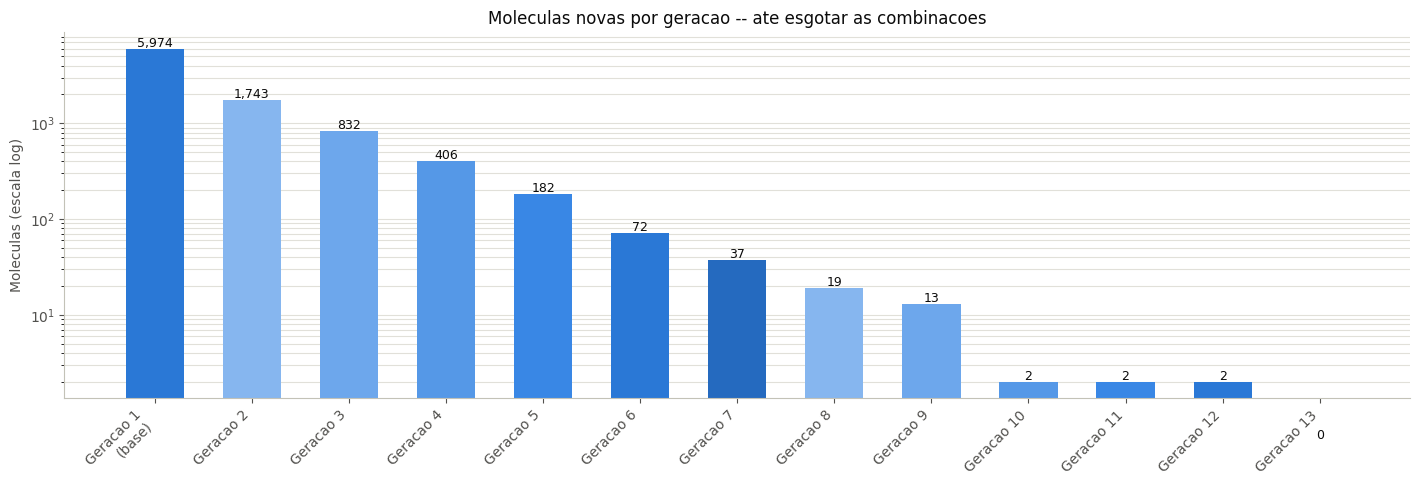

In [17]:
categorias_geracoes = ["Geracao 1\n(base)"] + [f"Geracao {g}" for g in df_metricas_geracoes["geracao"]]
valores_geracoes = [tamanho_base_original] + list(df_metricas_geracoes["moleculas_novas"])
cores_geracoes = [PALETA["azul"]] + [
    PALETA["ordinal_funil"][i % len(PALETA["ordinal_funil"])] for i in range(len(df_metricas_geracoes))
]

fig, ax = plt.subplots(figsize=(max(6, 1.1 * len(categorias_geracoes)), 5))
barras = ax.bar(categorias_geracoes, valores_geracoes, color=cores_geracoes, width=0.6)

for barra, valor in zip(barras, valores_geracoes):
    altura = barra.get_height()
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        altura * 1.05 if altura > 0 else 0.5,
        f"{valor:,}",
        ha="center",
        color=PALETA["texto_primario"],
        fontsize=9,
    )

ax.set_ylabel("Moleculas (escala log)")
ax.set_yscale("log")
ax.set_title("Moleculas novas por geracao -- ate esgotar as combinacoes")
ax.grid(axis="y", color=PALETA["grade"], linewidth=0.8, which="both")
ax.set_axisbelow(True)
estilizar_eixos(ax)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


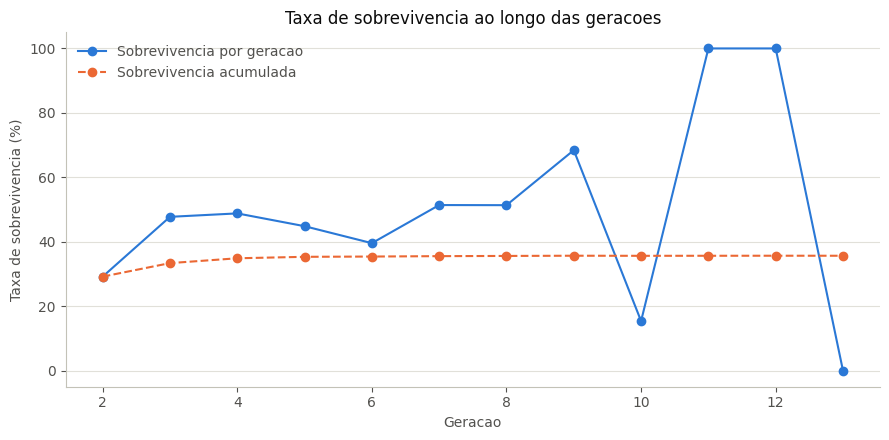

In [18]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(df_metricas_geracoes["geracao"], df_metricas_geracoes["taxa_sobrevivencia"] * 100,
        marker="o", color=PALETA["azul"], label="Sobrevivencia por geracao")
ax.plot(df_metricas_geracoes["geracao"], df_metricas_geracoes["taxa_sobrevivencia_acumulada"] * 100,
        marker="o", color=PALETA["laranja"], linestyle="--", label="Sobrevivencia acumulada")

ax.set_xlabel("Geracao")
ax.set_ylabel("Taxa de sobrevivencia (%)")
ax.set_title("Taxa de sobrevivencia ao longo das geracoes")
ax.legend(frameon=False, labelcolor=PALETA["texto_secundario"])
ax.grid(axis="y", color=PALETA["grade"], linewidth=0.8)
ax.set_axisbelow(True)
estilizar_eixos(ax)
plt.tight_layout()
plt.show()


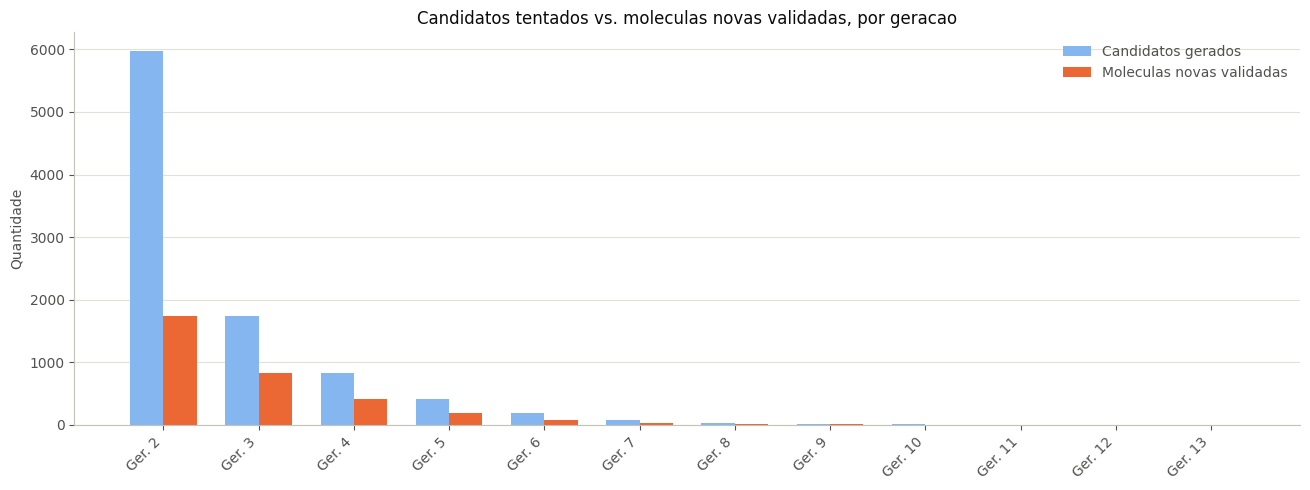

In [19]:
largura = 0.35
posicoes = range(len(df_metricas_geracoes))

fig, ax = plt.subplots(figsize=(max(6, 1.1 * len(df_metricas_geracoes)), 5))
ax.bar([p - largura / 2 for p in posicoes], df_metricas_geracoes["candidatos_gerados"],
       width=largura, color=PALETA["ordinal_funil"][0], label="Candidatos gerados")
ax.bar([p + largura / 2 for p in posicoes], df_metricas_geracoes["moleculas_novas"],
       width=largura, color=PALETA["laranja"], label="Moleculas novas validadas")

ax.set_xticks(list(posicoes))
ax.set_xticklabels([f"Ger. {g}" for g in df_metricas_geracoes["geracao"]], rotation=45, ha="right")
ax.set_ylabel("Quantidade")
ax.set_title("Candidatos tentados vs. moleculas novas validadas, por geracao")
ax.legend(frameon=False, labelcolor=PALETA["texto_secundario"])
ax.grid(axis="y", color=PALETA["grade"], linewidth=0.8)
ax.set_axisbelow(True)
estilizar_eixos(ax)
plt.tight_layout()
plt.show()


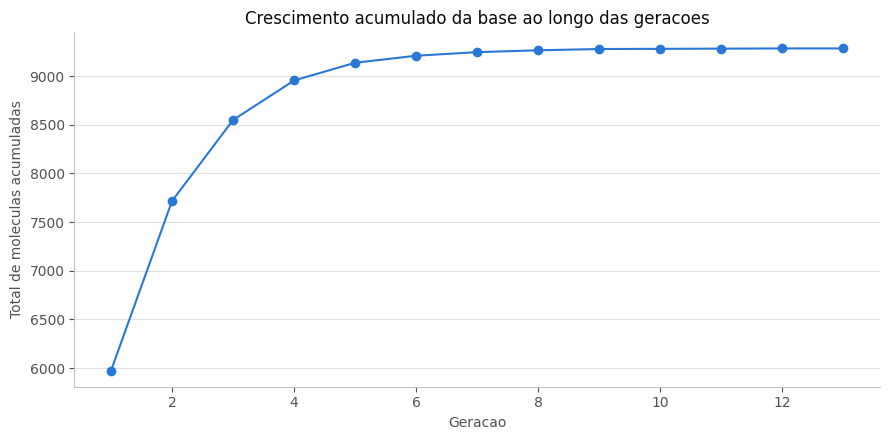

In [20]:
fig, ax = plt.subplots(figsize=(9, 4.5))
eixo_x = [1] + list(df_metricas_geracoes["geracao"])
eixo_y = [tamanho_base_original] + list(df_metricas_geracoes["moleculas_acumuladas"])

ax.plot(eixo_x, eixo_y, marker="o", color=PALETA["azul"])
ax.set_xlabel("Geracao")
ax.set_ylabel("Total de moleculas acumuladas")
ax.set_title("Crescimento acumulado da base ao longo das geracoes")
ax.grid(axis="y", color=PALETA["grade"], linewidth=0.8)
ax.set_axisbelow(True)
estilizar_eixos(ax)
plt.tight_layout()
plt.show()


## 12. Conclusão

O loop refaz, geração após geração, o mesmo ciclo que a versão anterior
deste notebook fazia manualmente para a Geração 3: reconstruir o catálogo a
partir do histórico acumulado, formar pares diversos por Zhang–Shasha,
montar candidatos e validar em duas fases contra tudo que já existe. A
diferença é que, a cada rodada, só as moléculas **novas** da geração
anterior viram semente para os próximos candidatos (não o histórico
inteiro) — isso evita que o número de candidatos exploda geometricamente, e
faz o loop convergir sozinho até a condição de parada: uma geração inteira
sem nenhuma molécula nova, ou o teto de segurança, o que vier primeiro.


In [21]:
print("CONCLUSAO")
print("-" * 70)
print(f"O loop rodou {n_geracoes_novas} geracao(oes) nova(s) a partir da base "
      f"original de {tamanho_base_original:,} moleculas. A cada rodada, so as "
      f"moleculas novas da geracao anterior viraram semente para novos "
      f"candidatos (buscando parceiros em todo o catalogo historico), o que "
      f"faz o numero de candidatos encolher a cada geracao ate convergir.")
print()
if motivo_parada == "sem_moleculas_novas":
    detalhe_parada = "nenhuma molecula nova sobreviveu na ultima geracao testada"
else:
    detalhe_parada = f"teto de seguranca de {MAX_GERACOES_SEGURANCA} geracoes novas atingido"
print(f"Parada: {motivo_parada} ({detalhe_parada}).")
print()
print(f"No total, {total_candidatos_tentados:,} arvores (anel + ponte + anel) foram "
      f"montadas e validadas ao longo de todas as geracoes; {total_moleculas_novas:,} "
      f"sobreviveram as duas fases de validacao -- uma sobrevivencia global de "
      f"{taxa_sobrevivencia_global:.2%}.")
print()
print(f"Valor final: {tamanho_final_total:,} moleculas (base original + todas as "
      f"geracoes novas), um crescimento de {crescimento_total:.2%} sobre a base "
      f"de entrada.")


CONCLUSAO
----------------------------------------------------------------------
O loop rodou 12 geracao(oes) nova(s) a partir da base original de 5,974 moleculas. A cada rodada, so as moleculas novas da geracao anterior viraram semente para novos candidatos (buscando parceiros em todo o catalogo historico), o que faz o numero de candidatos encolher a cada geracao ate convergir.

Parada: sem_moleculas_novas (nenhuma molecula nova sobreviveu na ultima geracao testada).

No total, 9,284 arvores (anel + ponte + anel) foram montadas e validadas ao longo de todas as geracoes; 3,310 sobreviveram as duas fases de validacao -- uma sobrevivencia global de 35.65%.

Valor final: 9,284 moleculas (base original + todas as geracoes novas), um crescimento de 55.41% sobre a base de entrada.
